# Proyecto Data Science : Hacking The Human Body
En esta segunda parte se elige y se prueba los modelos más aptos para el reconocimiento de tejidos. Basado en la investigación previa, emplearemos diferentes métricas de rendimiento, exactitud y precisión para determinar cuál provee los mejores resultados.

## Investigación de los modelos más aptos

## CNN
Las CNN (Convolutionary Neural Networks), Redes Neuronales Convolucionares en español, son un conjunto de redes cuya especialización es el reconocimiento de imágenes. Usalmente utilizadas para la clasificación o corrección de imágenes, estas poseen fuertes capacidades para lo que nosotros buscamos con este proyecto. Identificar diferentes tipos de tejidos corporales correctamente. 
Ahora bien, los modelos CNN como previamente dicho son buenos para identificar correctamente imágenes o son efectivos para su clasificación. Sin embargo, en este problema, queremos identificar los FTU que existen dentro de las imágenes e identificar cada uno respecto a sus tejidos. Por lo tanto, necesitaremos más ayuda que meramente una CNN para lograr identificar la imagen si no también identificar sus características internas. 

### ResNet con U-Net
La ResNet o Residual Network es un tipo de CNN que se enfoca en solucionar algunos problemas que padecen las redes neuronales convolucionarias normales. Esta red mejora el gradiente desvaneciente (cuando el gradiente se hace muy chico y retrasa el aprendizaje) mediante la omisión de conexiones entre ciertas capas que le permite evitar que eso ocurra durante el backpropagation. Sin embargo, como necesitamos también detectar los FTU, utilizamos U-Net junto con ResNet, logramos detectar features con ResNet y como encoder y U-Net como encoder para regresar a resolución completa.



### Referencias 
- Leonardo Reginato (14 October 2024) [A Practical Comparison Between CNN and ResNet Architectures: A Focus on Attention Mechanisms](https://medium.com/@leonardofonseca.r/a-practical-comparison-between-cnn-and-resnet-architectures-a-focus-on-attention-mechanisms-cee7ec8eca55)
- Yakub A. Bayhaqi, Arsham Hamidi, Ferda Canbaz, Alexander A. Navarini, Philippe C. Cattin, and Azhar Zam (2021) [Deep learning models comparison for tissue classification using optical coherence tomography images: toward smart laser osteotomy ](https://opg.optica.org/osac/fulltext.cfm?uri=osac-4-9-2510)
- Jie Li, Weiwei Goh, Noor Zaman Jhanjhi (16 October 2025) [A lightweight CNN for colon cancer tissue classification and visualization](https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.2025.1659010/full)
- Siddhesh Bangar (28 June 2022) [VGG-Net Architecture Explained](https://medium.com/@siddheshb008/vgg-net-architecture-explained-71179310050f)

In [1]:
# verify CUDA and PyTorch 
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


2.9.0
CUDA available: False
Device: CPU only


### Binary masks
Se le aplica máscaras binarias a los polígonos dados en train_annotations para las coordenadas.

In [2]:
import json, os, cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
import glob
from pathlib import Path
import matplotlib.pyplot as plt



In [3]:

def polygons_to_masks(path: str | Path, image_shape):
    with open(path, 'r') as f:
        data = json.load(f)

    mask = np.zeros(image_shape[:2], dtype=np.uint8)
    for polygon in data:
        pts = np.array(polygon, dtype=np.int32)
        cv2.fillPoly(mask, [pts], color=1)
    return mask


In [4]:
IMAGE_DIR = Path("data/train_images")
ANNOT_DIR = Path("data/train_annotations")
OUTPUT_IMG_DIR = Path("data/processed/images")
OUTPUT_MASK_DIR = Path("data/processed/masks")
OUTPUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_MASK_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = (512, 512)  # (width, height)

In [5]:
for image_path in tqdm(sorted(IMAGE_DIR.glob("*.tiff"))):
    name = image_path.stem
    json_path = ANNOT_DIR / f"{name}.json"
    if not json_path.exists():
        continue # skip iteration
    
    # image
    img = np.array(Image.open(image_path).convert("RGB"))
    h,w = img.shape[:2]
    mask = polygons_to_masks(json_path, (h, w, 3))

    # mask
    img_resized  = cv2.resize(img,  TARGET_SIZE, interpolation=cv2.INTER_AREA)
    mask_resized = cv2.resize(mask, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)

    # save
    cv2.imwrite(str(OUTPUT_IMG_DIR / f"{name}.png"), cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_MASK_DIR / f"{name}_mask.png"), mask_resized * 255)

0it [00:00, ?it/s]


In [6]:
# display image with mask to make sure it was done properly 
img  = cv2.imread(str(next(OUTPUT_IMG_DIR.glob("*.png"))))
mask = cv2.imread(str(next(OUTPUT_MASK_DIR.glob("*.png"))), 0)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.imshow(mask, cmap='Reds', alpha=0.4)
plt.axis('off')
plt.show()

StopIteration: 

In [ ]:
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
import random


class FtuSegDataset(Dataset):

    def __init__(self, img_dir: Path, mask_dir: Path, augment: bool=False) -> None:
        self.img_dir: Path = Path(img_dir)
        self.mask_dir: Path = Path(mask_dir)
        self.augment: bool = augment
        self.images: list[Path] = sorted([p for p in self.img_dir.glob("*.png")])

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        name = img_path.stem
        mask_path = self.mask_dir / f"{name}_mask.png"
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L") 

        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()  # [1,H,W], {0,1}

        # simple paired augmentations
        if self.augment:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() < 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

        # normalize 
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        image = (image - mean) / std

        return image, mask

In [ ]:
# create train / val test split
from torch.utils.data import DataLoader, random_split

root = Path("data/processed")
img_dir = root / "images"
mask_dir = root / "masks"


full_dataset = FtuSegDataset(img_dir, mask_dir, augment=True)

val_fraction: float = 0.2
val_size = int(len(full_dataset) * val_fraction)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# no random augment on val
val_dataset.dataset.augment = False

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

### ResNet & U-Net

In [ ]:
import torch.nn as nn
import segmentation_models_pytorch as smp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)


c:\Users\lpmon\Documents\GitHub\Hacking-the-Human-Body\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# calculate loss 
bce = nn.BCEWithLogitsLoss()

# utilize Dice coefficient to measure 
# 2 * |X ∩ Y| / |X| + |Y|
def dice_loss(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2,3))
    den = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + eps
    return 1 - (num / den).mean()

def combo_loss(logits, targets, alpha=0.5):
    return alpha * bce(logits, targets) + (1 - alpha) * dice_loss(logits, targets)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
# run epochs to train

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images, masks in tqdm(loader, leave=False):
        images = images.to(device)
        masks = masks.to(device)

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = combo_loss(logits, masks)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # metrics
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            # Dice for monitoring
            inter = (preds * masks).sum(dim=(2,3))
            union = preds.sum(dim=(2,3)) + masks.sum(dim=(2,3))
            dice = ((2 * inter + 1e-7) / (union + 1e-7)).mean()

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_dice += dice.item() * bs

    n = len(loader.dataset)
    return total_loss / n, total_dice / n

NUM_EPOCHS = 10 # TODO increate the number of epochs, check if that makes a better result

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_dice = run_epoch(train_loader, train=True)
    val_loss, val_dice = run_epoch(val_loader,   train=False)
    
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f}  train_dice={train_dice:.4f} | val_loss={val_loss:.4f}  val_dice={val_dice:.4f}")


Epoch 01 | train_loss=0.6458  train_dice=0.3592 | val_loss=0.5959  val_dice=0.4797


Epoch 02 | train_loss=0.5153  train_dice=0.5546 | val_loss=0.4859  val_dice=0.5441


Epoch 03 | train_loss=0.4309  train_dice=0.6364 | val_loss=0.4167  val_dice=0.6083


Epoch 04 | train_loss=0.3732  train_dice=0.6904 | val_loss=0.3863  val_dice=0.6023


Epoch 05 | train_loss=0.3300  train_dice=0.7087 | val_loss=0.3543  val_dice=0.6106


Epoch 06 | train_loss=0.2955  train_dice=0.7358 | val_loss=0.3429  val_dice=0.6176


Epoch 07 | train_loss=0.2460  train_dice=0.7808 | val_loss=0.3153  val_dice=0.6359


Epoch 08 | train_loss=0.2207  train_dice=0.7924 | val_loss=0.3251  val_dice=0.5943


Epoch 09 | train_loss=0.2028  train_dice=0.8049 | val_loss=0.2988  val_dice=0.6201


Epoch 10 | train_loss=0.1860  train_dice=0.8144 | val_loss=0.2712  val_dice=0.6465


In [ ]:
# evaluate results
model.eval()
images, masks = next(iter(val_loader))
images = images.to(device)
with torch.no_grad():
    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()


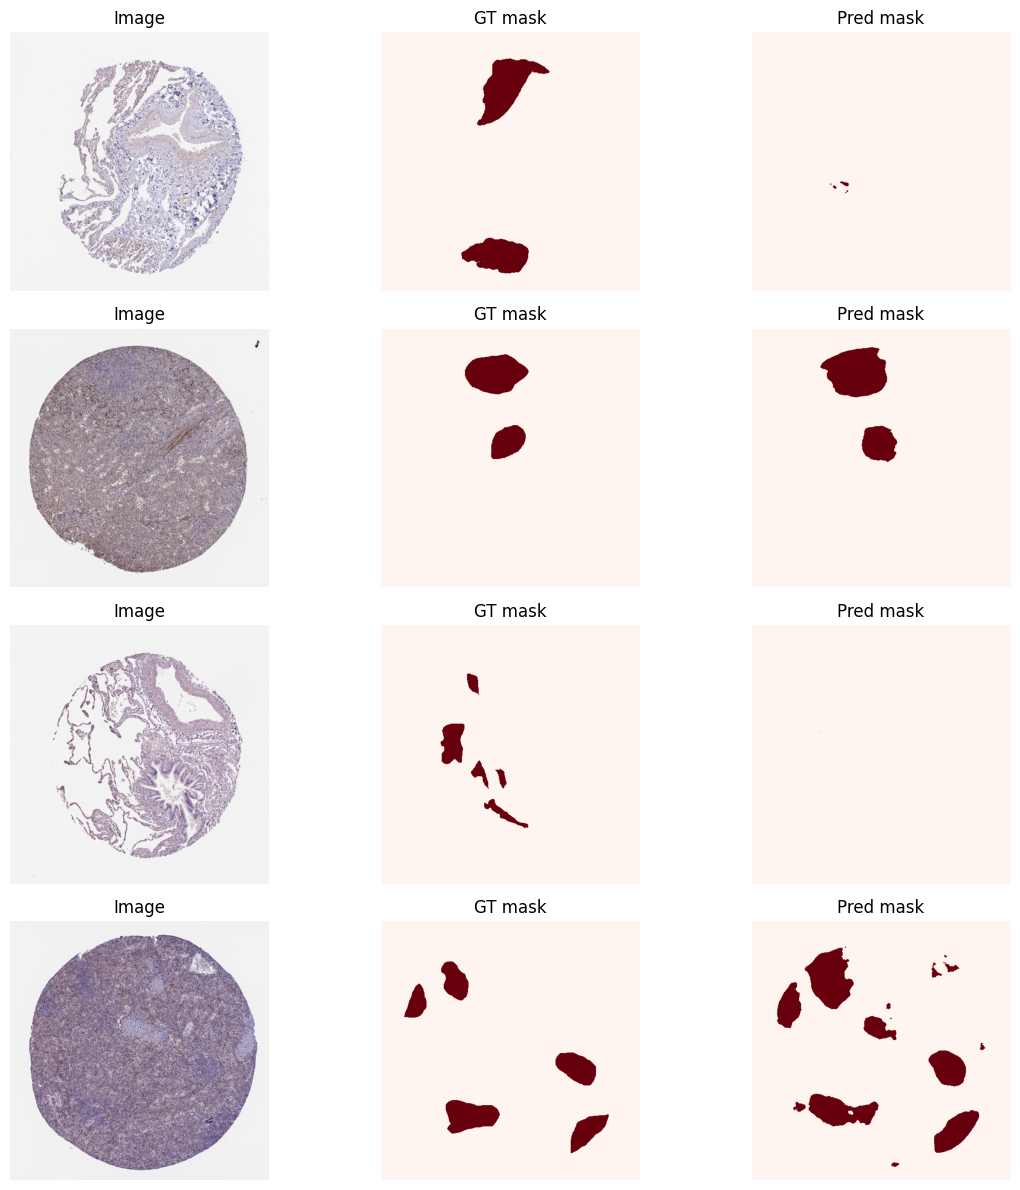

In [ ]:

# visualize 
n_show = min(6, len(images))   # show up to 5 samples
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(n_show, 3, figsize=(12, 3*n_show))

for i in range(n_show):
    img_np = images[i].cpu()
    img_np = (img_np * std + mean).clamp(0,1).permute(1,2,0).numpy()

    gt = masks[i,0].cpu().numpy()
    pr = preds[i,0].cpu().numpy()

    axes[i,0].imshow(img_np); axes[i,0].set_title("Image"); axes[i,0].axis("off")
    axes[i,1].imshow(gt, cmap="Reds"); axes[i,1].set_title("GT mask"); axes[i,1].axis("off")
    axes[i,2].imshow(pr, cmap="Reds"); axes[i,2].set_title("Pred mask"); axes[i,2].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
def evaluate_overall(model, loader, device, threshold=0.5):
    """
    Evaluate overall performance (mean Dice & IoU) using the existing dice_loss().
    Computes average metrics per image without storing pixel arrays.
    """
    model.eval()
    total_dice = 0.0
    total_iou  = 0.0
    n_images   = 0
    eps = 1e-7

    print("Evaluando desempeño global (promedio por imagen)...")
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Procesando batches"):
            images = images.to(device)
            masks  = masks.to(device)

            logits = model(images)
            probs  = torch.sigmoid(logits)
            preds  = (probs > threshold).float()

            # ---- reuse existing dice_loss() ----
            # dice_loss = 1 - soft_dice
            soft_dice_score = 1.0 - dice_loss(logits, masks)
            total_dice += soft_dice_score.item() * images.size(0)

            # IoU from hard predictions
            gt = masks[:, 0]
            pr = preds[:, 0]
            intersection = (gt * pr).sum(dim=(1, 2))
            union = gt.sum(dim=(1, 2)) + pr.sum(dim=(1, 2)) - intersection
            iou = (intersection + eps) / (union + eps)
            total_iou += iou.mean().item() * images.size(0)

            n_images += images.size(0)

    mean_dice = total_dice / max(n_images, 1)
    mean_iou  = total_iou  / max(n_images, 1)

    print("============================================================")
    print("MÉTRICAS GLOBALES (Promedio por imagen)")
    print("============================================================")
    print(f"Dice medio: {mean_dice:.4f}")
    print(f"IoU medio : {mean_iou:.4f}")
    print(f"Imágenes evaluadas: {n_images}")
    print("============================================================")

    return {
        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "n_images": n_images,
    }

In [ ]:
metrics = evaluate_overall(model, val_loader, device)

Evaluando desempeño global (promedio por imagen)...


Procesando batches: 100%|██████████| 18/18 [00:01<00:00, 15.17it/s]

MÉTRICAS GLOBALES (Promedio por imagen)
Dice medio: 0.5903
IoU medio : 0.5469
Imágenes evaluadas: 70


### DeepLab V3+

In [ ]:
# Inicializar modelo DeepLab V3+ con ResNet-50 como backbone
model_deeplab = smp.DeepLabV3Plus(
    encoder_name="resnet50",           # Backbone: ResNet-50 
    encoder_weights="imagenet",        # Pesos pre-entrenados en ImageNet
    in_channels=3,                     # RGB
    classes=1,                         # Segmentación binaria (FTU vs background)
    encoder_output_stride=16,          # Control de resolución en el encoder
    decoder_atrous_rates=(12, 24, 36), # Dilation rates del ASPP
    decoder_channels=256               # Canales en el decoder
).to(device)

print(f"Modelo DeepLab V3+ inicializado en: {device}")
print(f"Parámetros totales: {sum(p.numel() for p in model_deeplab.parameters()):,}")

c:\Users\javil\OneDrive\Documentos\U\Data Science\Hacking-the-Human-Body\.venv312\Lib\site-packages\huggingface_hub\file_download.py:121: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\javil\.cache\huggingface\hub\models--smp-hub--resnet50.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Modelo DeepLab V3+ inicializado en: cuda
Parámetros totales: 26,677,585


In [ ]:
# Configurar optimizer y loss para DeepLab V3+
optimizer_deeplab = torch.optim.Adam(model_deeplab.parameters(), lr=1e-4)
print("Optimizer configurado con lr=1e-4")
print("Loss function: combo_loss (BCE + Dice)")

Optimizer configurado con lr=1e-4
Loss function: combo_loss (BCE + Dice)


In [ ]:
# Entrenar DeepLab V3+
def run_epoch_deeplab(loader, train=True):
    if train:
        model_deeplab.train()
    else:
        model_deeplab.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images, masks in tqdm(loader, leave=False):
        images = images.to(device)
        masks = masks.to(device)

        with torch.set_grad_enabled(train):
            logits = model_deeplab(images)
            loss = combo_loss(logits, masks)

        if train:
            optimizer_deeplab.zero_grad()
            loss.backward()
            optimizer_deeplab.step()

        # metrics
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            # Dice for monitoring
            inter = (preds * masks).sum(dim=(2,3))
            union = preds.sum(dim=(2,3)) + masks.sum(dim=(2,3))
            dice = ((2 * inter + 1e-7) / (union + 1e-7)).mean()

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_dice += dice.item() * bs

    n = len(loader.dataset)
    return total_loss / n, total_dice / n

NUM_EPOCHS_DEEPLAB = 10 

print("Iniciando entrenamiento de DeepLab V3+...")
for epoch in range(1, NUM_EPOCHS_DEEPLAB + 1):
    train_loss, train_dice = run_epoch_deeplab(train_loader, train=True)
    val_loss, val_dice = run_epoch_deeplab(val_loader, train=False)
    
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f}  train_dice={train_dice:.4f} | val_loss={val_loss:.4f}  val_dice={val_dice:.4f}")

Iniciando entrenamiento de DeepLab V3+...


Epoch 01 | train_loss=0.6477  train_dice=0.3820 | val_loss=0.5793  val_dice=0.5000


Epoch 02 | train_loss=0.4850  train_dice=0.5289 | val_loss=0.4026  val_dice=0.6213


Epoch 03 | train_loss=0.3865  train_dice=0.6147 | val_loss=0.3437  val_dice=0.6376


Epoch 04 | train_loss=0.3119  train_dice=0.6930 | val_loss=0.3088  val_dice=0.6526


...

Epoch 06 | train_loss=0.2315  train_dice=0.7594 | val_loss=0.2801  val_dice=0.6501


Epoch 07 | train_loss=0.2051  train_dice=0.7851 | val_loss=0.2552  val_dice=0.6796


Epoch 08 | train_loss=0.1904  train_dice=0.7910 | val_loss=0.2566  val_dice=0.6824


Epoch 09 | train_loss=0.1655  train_dice=0.8224 | val_loss=0.2567  val_dice=0.6764


Epoch 10 | train_loss=0.1456  train_dice=0.8409 | val_loss=0.2451  val_dice=0.6794


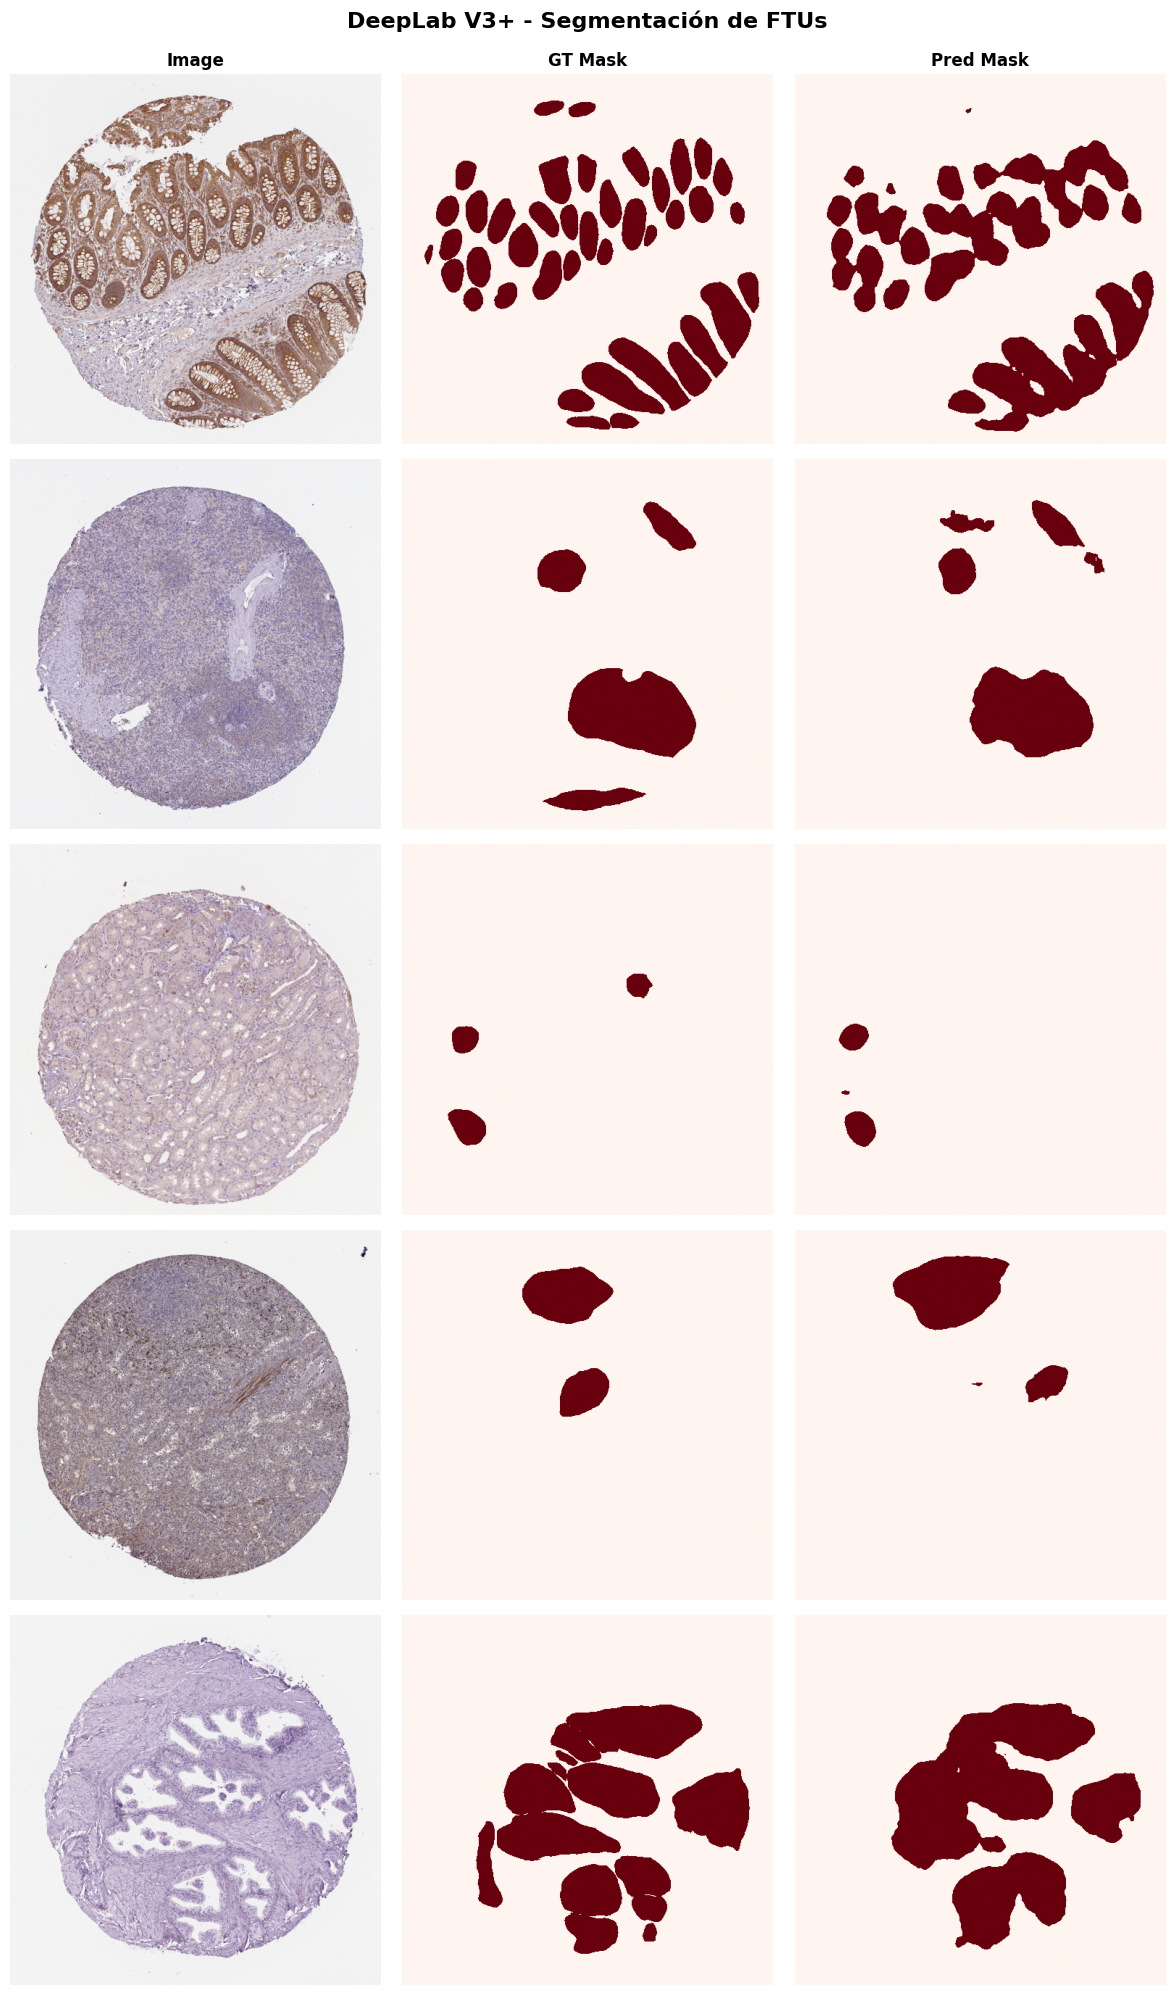

In [ ]:
# Evaluar resultados de DeepLab V3+
model_deeplab.eval()

val_iter = iter(val_loader)
batch1_img, batch1_mask = next(val_iter)
batch2_img, batch2_mask = next(val_iter)

images_dl = torch.cat([batch1_img, batch2_img[:1]], dim=0)[:5] 
masks_dl = torch.cat([batch1_mask, batch2_mask[:1]], dim=0)[:5]
images_dl = images_dl.to(device)
masks_dl = masks_dl.to(device)

with torch.no_grad():
    logits_dl = model_deeplab(images_dl)
    probs_dl = torch.sigmoid(logits_dl)
    preds_dl = (probs_dl > 0.5).float()

# visualizar las 5 muestras
fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for i in range(5):
    img_np = images_dl[i].cpu()
    
    # unnormalize for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_np = (img_np * std + mean).clamp(0,1).permute(1,2,0).numpy()
    
    gt = masks_dl[i,0].cpu().numpy()
    pr = preds_dl[i,0].cpu().numpy()
    
    # Plot
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("Image" if i == 0 else "", fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel(f"Sample {i+1}", fontsize=11, fontweight='bold')
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(gt, cmap="Reds")
    axes[i, 1].set_title("GT Mask" if i == 0 else "", fontsize=12, fontweight='bold')
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(pr, cmap="Reds")
    axes[i, 2].set_title("Pred Mask" if i == 0 else "", fontsize=12, fontweight='bold')
    axes[i, 2].axis("off")

plt.suptitle("DeepLab V3+ - Segmentación de FTUs", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

#### Análisis Cuantitativo: Valores Reales vs Predichos

In [ ]:
# Evaluar todo el conjunto de validación para análisis detallado
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

model_deeplab.eval()

all_gt_pixels = []
all_pred_pixels = []
all_gt_probs = []
all_pred_probs = []
per_image_metrics = []

print("Evaluando conjunto de validación completo...")
with torch.no_grad():
    for idx, (images, masks) in enumerate(tqdm(val_loader, desc="Procesando batches")):
        images = images.to(device)
        masks = masks.to(device)
        
        logits = model_deeplab(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        
        # Convertir a numpy y aplanar
        for i in range(images.size(0)):
            gt_mask = masks[i, 0].cpu().numpy().flatten()
            pred_mask = preds[i, 0].cpu().numpy().flatten()
            pred_prob = probs[i, 0].cpu().numpy().flatten()
            
            all_gt_pixels.extend(gt_mask)
            all_pred_pixels.extend(pred_mask)
            all_gt_probs.extend(gt_mask)
            all_pred_probs.extend(pred_prob)
            
            # Calcular métricas por imagen
            intersection = (pred_mask * gt_mask).sum()
            union = pred_mask.sum() + gt_mask.sum() - intersection
            iou = (intersection + 1e-7) / (union + 1e-7)
            dice = (2 * intersection + 1e-7) / (pred_mask.sum() + gt_mask.sum() + 1e-7)
            
            per_image_metrics.append({
                'image_idx': idx * images.size(0) + i,
                'IoU': iou,
                'Dice': dice,
                'GT_pixels': gt_mask.sum(),
                'Pred_pixels': pred_mask.sum()
            })

# Convertir a arrays
all_gt_pixels = np.array(all_gt_pixels)
all_pred_pixels = np.array(all_pred_pixels)
all_pred_probs = np.array(all_pred_probs)

print(f"✓ Total píxeles evaluados: {len(all_gt_pixels):,}")

Evaluando conjunto de validación completo...


Procesando batches: 100%|██████████| 18/18 [00:07<00:00,  2.32it/s]


✓ Total píxeles evaluados: 18,350,080


In [ ]:
# 1. Métricas globales a nivel de píxel
accuracy = accuracy_score(all_gt_pixels, all_pred_pixels)
precision = precision_score(all_gt_pixels, all_pred_pixels, zero_division=0)
recall = recall_score(all_gt_pixels, all_pred_pixels, zero_division=0)
f1 = f1_score(all_gt_pixels, all_pred_pixels, zero_division=0)

# Confusion Matrix
cm = confusion_matrix(all_gt_pixels, all_pred_pixels)
tn, fp, fn, tp = cm.ravel()

print("="*60)
print("MÉTRICAS GLOBALES DE DeepLab V3+ (Nivel de Píxel)")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives:  {tp:,}")
print("="*60)

MÉTRICAS GLOBALES DE DeepLab V3+ (Nivel de Píxel)
Accuracy:  0.9571 (95.71%)
Precision: 0.8383 (83.83%)
Recall:    0.7620 (76.20%)
F1-Score:  0.7984

Confusion Matrix:
  True Negatives:  16,005,203
  False Positives: 300,433
  False Negatives: 486,483
  True Positives:  1,557,961


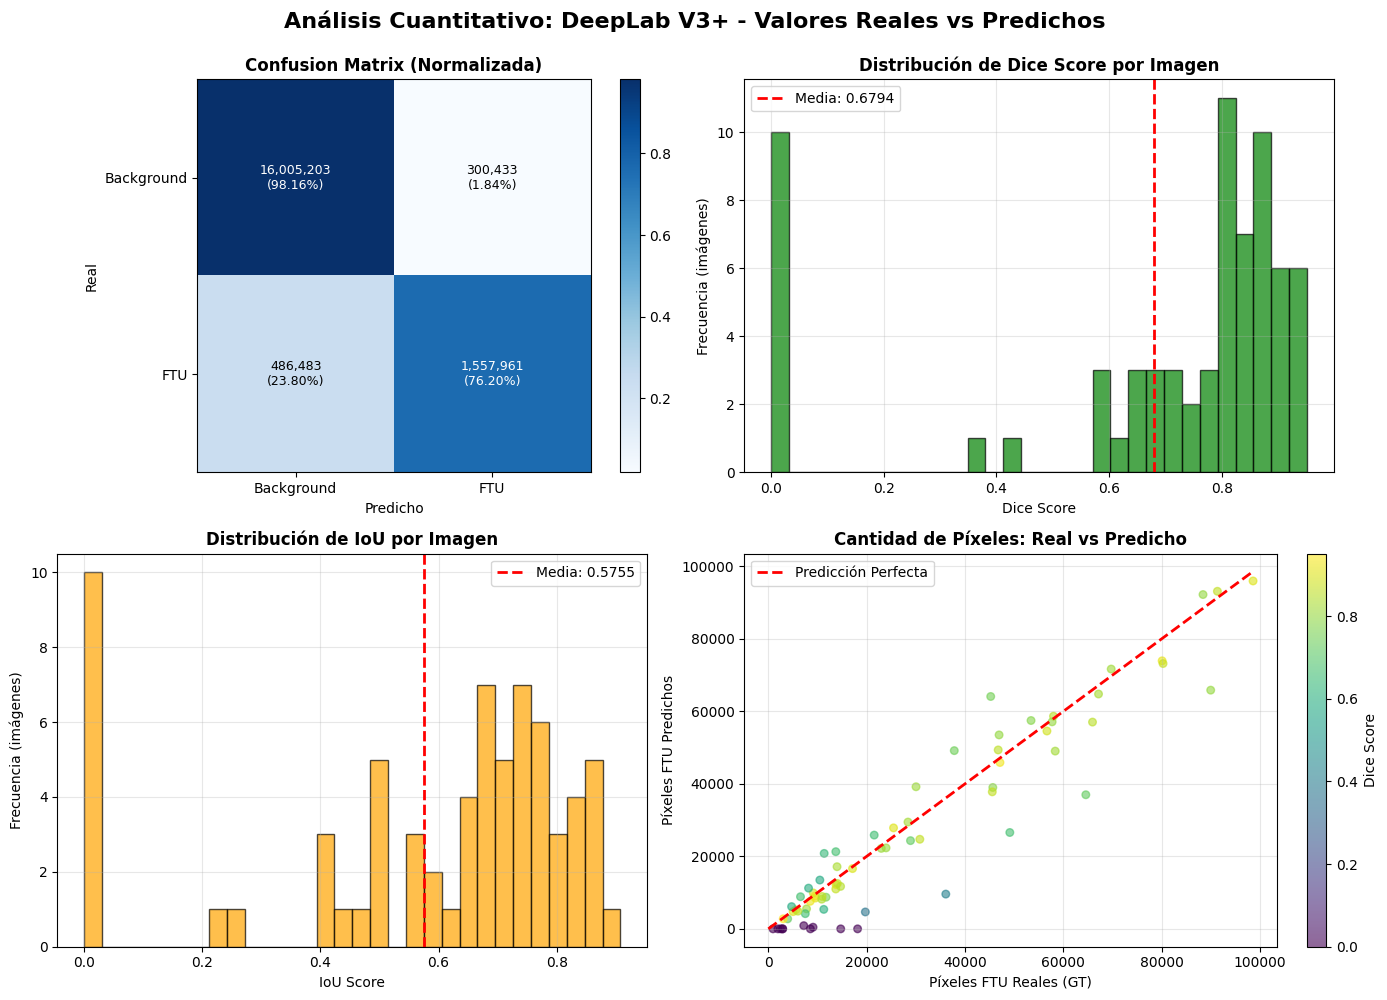

In [ ]:
# 2. Visualizaciones: Valores Reales vs Predichos

df_metrics = pd.DataFrame(per_image_metrics)
fig = plt.figure(figsize=(14, 10))

# 2.1 Confusion Matrix (Heatmap)
ax1 = plt.subplot(2, 2, 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax1.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
ax1.set_title('Confusion Matrix (Normalizada)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicho', fontsize=10)
ax1.set_ylabel('Real', fontsize=10)
tick_marks = np.arange(2)
ax1.set_xticks(tick_marks)
ax1.set_yticks(tick_marks)
ax1.set_xticklabels(['Background', 'FTU'])
ax1.set_yticklabels(['Background', 'FTU'])

# Añadir valores en las celdas
for i in range(2):
    for j in range(2):
        text = ax1.text(j, i, f'{cm[i, j]:,}\n({cm_normalized[i, j]:.2%})',
                       ha="center", va="center", color="white" if cm_normalized[i, j] > 0.5 else "black",
                       fontsize=9)
plt.colorbar(im, ax=ax1, fraction=0.046)

# 2.2 Distribución de Dice Score por Imagen
ax2 = plt.subplot(2, 2, 2)
ax2.hist(df_metrics['Dice'], bins=30, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(df_metrics['Dice'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Media: {df_metrics["Dice"].mean():.4f}')
ax2.set_xlabel('Dice Score', fontsize=10)
ax2.set_ylabel('Frecuencia (imágenes)', fontsize=10)
ax2.set_title('Distribución de Dice Score por Imagen', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 2.3 Distribución de IoU por Imagen
ax3 = plt.subplot(2, 2, 3)
ax3.hist(df_metrics['IoU'], bins=30, alpha=0.7, color='orange', edgecolor='black')
ax3.axvline(df_metrics['IoU'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Media: {df_metrics["IoU"].mean():.4f}')
ax3.set_xlabel('IoU Score', fontsize=10)
ax3.set_ylabel('Frecuencia (imágenes)', fontsize=10)
ax3.set_title('Distribución de IoU por Imagen', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 2.4 Relación entre Píxeles GT vs Pred por Imagen
ax4 = plt.subplot(2, 2, 4)
ax4.scatter(df_metrics['GT_pixels'], df_metrics['Pred_pixels'], 
           c=df_metrics['Dice'], cmap='viridis', alpha=0.6, s=30)
max_pixels = max(df_metrics['GT_pixels'].max(), df_metrics['Pred_pixels'].max())
ax4.plot([0, max_pixels], [0, max_pixels], 'r--', linewidth=2, label='Predicción Perfecta')
ax4.set_xlabel('Píxeles FTU Reales (GT)', fontsize=10)
ax4.set_ylabel('Píxeles FTU Predichos', fontsize=10)
ax4.set_title('Cantidad de Píxeles: Real vs Predicho', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)
plt.colorbar(ax4.collections[0], ax=ax4, label='Dice Score', fraction=0.046)

plt.suptitle('Análisis Cuantitativo: DeepLab V3+ - Valores Reales vs Predichos', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()